In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from data_processing_utils import *

In [2]:
# DOUBLE CHECK NO TWO SENSORS IN SAME SEGMENT
speed_data = pd.read_csv("I_35W_data_raw/speedavg_SB.csv").to_numpy() * 1.60934  # convert to kph
flow_data = pd.read_csv("I_35W_data_raw/VOLavg_SB.csv").to_numpy()
print(speed_data.shape)

(73, 1441)


In [3]:
lanes_sb = np.load("I_35W_data_raw/lane_map_sb.npy")
on_ramp_sb = np.load("I_35W_data_raw/on_ramp_map_sb.npy")
off_ramp_sb = np.load("I_35W_data_raw/off_ramp_map_sb.npy")

# lanes_sb = pd.read_csv("I_35W_data_raw/normalized_lanes_rcs_southbound.csv")["lanes"].to_numpy().flatten()
# lanes_sb = np.flip(lanes_sb)

print(lanes_sb.shape)
print(on_ramp_sb.shape)
print(off_ramp_sb.shape)
# print(lanes_sb)

(71,)
(71,)
(71,)


In [4]:
data_freq = 60 # in seconds
metanet_time_step = 10

In [5]:
speed_data_full = np.flip(speed_data, axis=0)
flow_data_full = np.flip(flow_data, axis=0)
speed_data_full = np.repeat(speed_data_full, int(data_freq/metanet_time_step), axis = 1).T
flow_data_full = np.repeat(flow_data_full, int(data_freq/metanet_time_step), axis = 1).T

In [6]:
speed_data_full = np.where(speed_data_full <= 1e-3, 1e-3, speed_data_full)  # to avoid division by zero
flow_data_full = np.where(flow_data_full <= 1e-3, 1e-3, flow_data_full)  # to avoid division by zero
density_data_full = flow_data_full/speed_data_full


In [7]:
print(speed_data_full.shape)

(8646, 73)


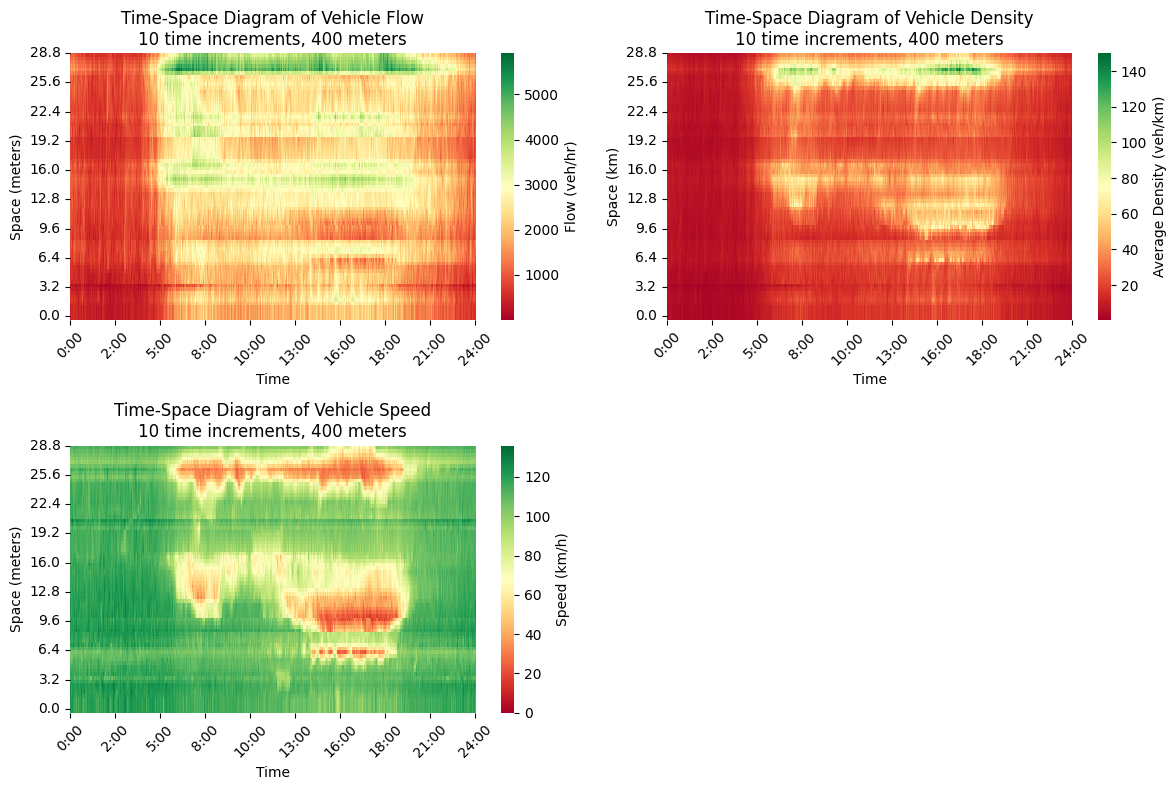

In [8]:
plot_matrices(
    np.flip(flow_data_full, axis=1),
    np.flip(density_data_full, axis=1),
    10,
    400,
    0,
    100,
    0,
    100,
)

In [14]:
# Get data on 2nd half of freeway from 4 pm to 6 pm
## SOUTHBOUND
# seg_start = int(9.6* 1000/400)  # 9.6 km mark
# seg_end = int(18 * 1000/400)  # 16 km mark

# print(seg_start, seg_end)

# time_start = int(7* 3600 / metanet_time_step)
# time_end = int(8.5 * 3600 / metanet_time_step)

## SOUTHBOUND 2
# seg_start = int(8* 1000/400)  # 9.6 km mark
# seg_end = int(18 * 1000/400)  # 16 km mark

# print(seg_start, seg_end)

# time_start = int(12* 3600 / metanet_time_step)
# time_end = int(20 * 3600 / metanet_time_step)

#SOUTHBOUND 3
# seg_start = int(7* 1000/400)  # 9.6 km mark
# seg_end = int(16 * 1000/400)  # 16 km mark

# print(seg_start, seg_end)

# time_start = int(16.5* 3600 / metanet_time_step)
# time_end = int(18.5 * 3600 / metanet_time_step)

# #SOUTHBOUND 4
# seg_start = int(21* 1000/400)  # 9.6 km mark
# seg_end = int(30 * 1000/400)  # 16 km mark

# print(seg_start, seg_end)

# time_start = int(16.5* 3600 / metanet_time_step)
# time_end = int(18.5 * 3600 / metanet_time_step)

#SOUTHBOUND 5
seg_start = int(3* 1000/400)  # 9.6 km mark
seg_end = int(16 * 1000/400)  # 16 km mark

print(seg_start, seg_end)

time_start = int(16.5* 3600 / metanet_time_step)
time_end = int(18.5 * 3600 / metanet_time_step)

# ##NORTHBOUND
# seg_start = int(9* 1000/400)  # 9.6 km mark
# seg_end = int(17.5 * 1000/400)  # 16 km mark

# print(seg_start, seg_end)

# time_start = int(5.2* 3600 / metanet_time_step)
# time_end = int(7.2 * 3600 / metanet_time_step)

speed_data_short = speed_data_full[time_start:time_end, seg_start:seg_end]
flow_data_short = flow_data_full[time_start:time_end, seg_start:seg_end]
density_data_short = density_data_full[time_start:time_end, seg_start:seg_end]

lanes_short = lanes_sb[seg_start:seg_end-2]
on_ramp_short = on_ramp_sb[seg_start:seg_end-2]
off_ramp_short = off_ramp_sb[seg_start:seg_end-2]

7 40


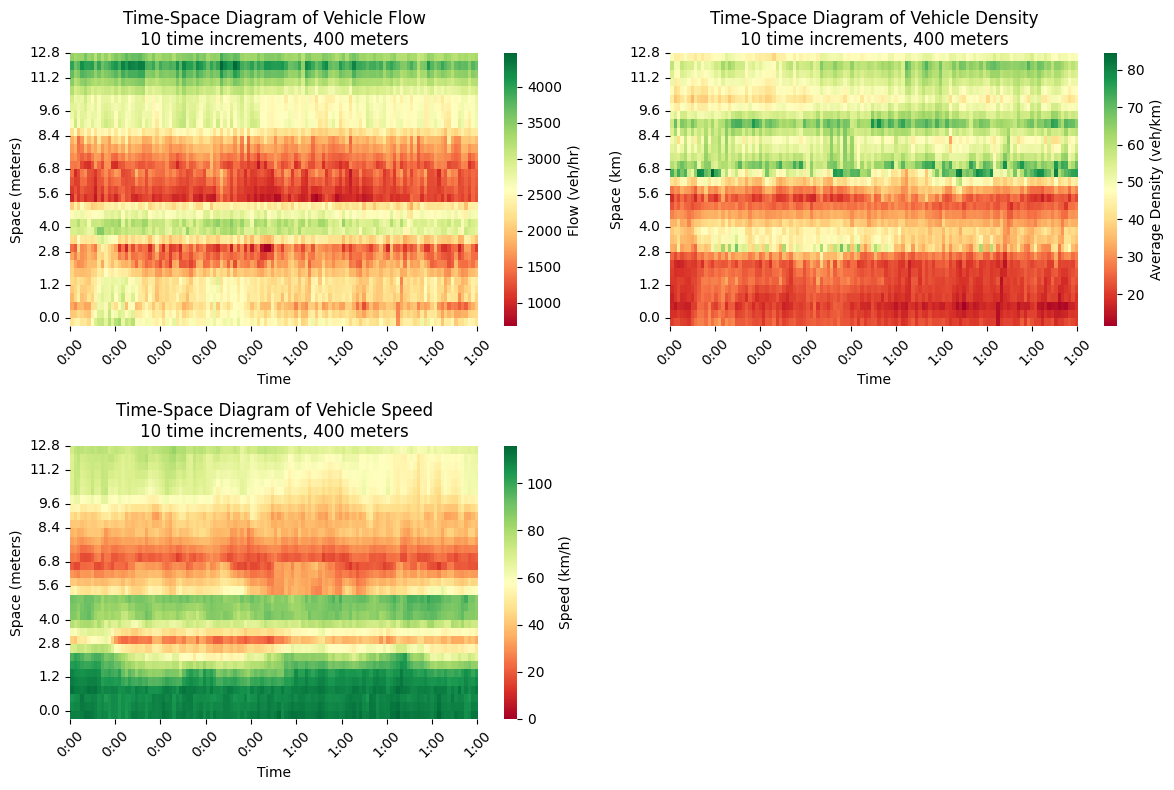

In [15]:
plot_matrices(
    np.flip(flow_data_short, axis=1),
    np.flip(density_data_short, axis=1),
    10,
    400,
    0,
    100,
    0,
    100,
)

In [16]:
np.save("data/i35_southbound/i35_sb5_flow_10sec_400m.npy", flow_data_short)
np.save("data/i35_southbound/i35_sb5_velocity_10sec_400m.npy", speed_data_short)
np.save("data/i35_southbound/i35_sb5_density_10sec_400m.npy", density_data_short)
np.save("data/i35_southbound/lanes_sb5.npy", lanes_short)
np.save("data/i35_southbound/on_ramps_sb5.npy", on_ramp_short)
np.save("data/i35_southbound/off_ramps_sb5.npy", off_ramp_short)